In [1]:
import pandas as pd
import mendeleev
from mendeleev import element

In [ ]:
# ML(Metal(Ag, au , cu) + X (f, CL, Br, I, CN) + Donor) + QM (QTAIM + d + Monomer_Slippage + H_X + M_N_distance)= Interaction (output)

In [2]:
df = pd.read_csv(
    "updated_metallophilic_dataset.csv"
)

# View first rows
df.head()

,dimer,Metal,Ligand,X,R,Y_Smiles,E,d,rho,laplacian,V,G,V_over_G
0,Ag_1,Ag,CN,Cl,H,C#N,-6.16,3.038,0.0202,0.0575,-0.0155,0.0149,1.040
1,Ag_2,Ag,CN,Cl,F,FC#N,-6.57,3.013,0.0212,0.0607,-0.0167,0.0159,1.050
2,Ag_3,Ag,CN,Cl,CF3,FC(F)(F)C#N,-6.67,3.025,0.0208,0.0591,-0.0161,0.0155,1.039
3,Ag_4,Ag,CN,Cl,NO2,O=[N+]([O-])C#N,-6.58,3.013,0.0213,0.0607,-0.0167,0.0160,1.044
4,Ag_5,Ag,CN,Cl,CH3,CC#N,-6.00,3.038,0.0201,0.0576,-0.0155,0.0149,1.040


In [3]:
print("Metal Labels:")
print(df["Metal"].unique())

print("\nX Labels:")
print(df["X"].unique())

print("\nR Labels:")
print(df["R"].unique())

Metal Labels:
['Ag' 'Au' 'Cu']

X Labels:
['Cl' 'Br' 'I' 'CN' 'F']

R Labels:
['H' 'F' 'CF3' 'NO2' 'CH3' 'NH2' 'OH']


In [4]:
print(df.columns)

Index(['dimer', 'Metal', 'Ligand', 'X', 'R', 'Y_Smiles', 'E', 'd', 'rho',
       'laplacian', 'V', 'G', 'V_over_G'],
      dtype='object')


In [5]:
# =========================================================
# SAFE ELEMENT MAPPING
# =========================================================

def get_element_symbol(x):

    x = str(x).strip()

    # CN treated using donor carbon properties
    if x == "CN":
        return "C"

    return x

In [6]:
def extract_periodic_descriptors(symbol):

    symbol = get_element_symbol(symbol)

    el = element(symbol)

    descriptors = {

        "atomic_number": el.atomic_number,

        "atomic_radius": el.atomic_radius,

        "electronegativity": el.en_pauling,

        "polarizability": el.dipole_polarizability,

        "ionization_energy": el.ionenergies[1]

    }

    return descriptors

In [7]:
# =========================================================
# METAL DESCRIPTORS
# =========================================================

metal_descriptors = df["Metal"].apply(
    extract_periodic_descriptors
)

metal_df = pd.json_normalize(
    metal_descriptors
)

# Rename columns

metal_df.columns = [
    "Metal_" + col
    for col in metal_df.columns
]

# View

metal_df.head()

,Metal_atomic_number,Metal_atomic_radius,Metal_electronegativity,Metal_polarizability,Metal_ionization_energy
0,47,160.0,1.93,55.0,7.576234
1,47,160.0,1.93,55.0,7.576234
2,47,160.0,1.93,55.0,7.576234
3,47,160.0,1.93,55.0,7.576234
4,47,160.0,1.93,55.0,7.576234


In [8]:
# =========================================================
# X-LIGAND DESCRIPTORS
# =========================================================

X_descriptors = df["X"].apply(
    extract_periodic_descriptors
)

X_df = pd.json_normalize(
    X_descriptors
)

# Rename columns

X_df.columns = [
    "X_" + col
    for col in X_df.columns
]

# View

X_df.head()

,X_atomic_number,X_atomic_radius,X_electronegativity,X_polarizability,X_ionization_energy
0,17,100.0,3.16,14.6,12.96763
1,17,100.0,3.16,14.6,12.96763
2,17,100.0,3.16,14.6,12.96763
3,17,100.0,3.16,14.6,12.96763
4,17,100.0,3.16,14.6,12.96763


In [9]:
df = pd.concat(
    [df, metal_df, X_df],
    axis=1
)

# View updated dataframe

df.head()

,dimer,Metal,Ligand,X,R,Y_Smiles,E,d,rho,laplacian,...,Metal_atomic_number,Metal_atomic_radius,Metal_electronegativity,Metal_polarizability,Metal_ionization_energy,X_atomic_number,X_atomic_radius,X_electronegativity,X_polarizability,X_ionization_energy
0,Ag_1,Ag,CN,Cl,H,C#N,-6.16,3.038,0.0202,0.0575,...,47,160.0,1.93,55.0,7.576234,17,100.0,3.16,14.6,12.96763
1,Ag_2,Ag,CN,Cl,F,FC#N,-6.57,3.013,0.0212,0.0607,...,47,160.0,1.93,55.0,7.576234,17,100.0,3.16,14.6,12.96763
2,Ag_3,Ag,CN,Cl,CF3,FC(F)(F)C#N,-6.67,3.025,0.0208,0.0591,...,47,160.0,1.93,55.0,7.576234,17,100.0,3.16,14.6,12.96763
3,Ag_4,Ag,CN,Cl,NO2,O=[N+]([O-])C#N,-6.58,3.013,0.0213,0.0607,...,47,160.0,1.93,55.0,7.576234,17,100.0,3.16,14.6,12.96763
4,Ag_5,Ag,CN,Cl,CH3,CC#N,-6.00,3.038,0.0201,0.0576,...,47,160.0,1.93,55.0,7.576234,17,100.0,3.16,14.6,12.96763


In [10]:
print(
    df.isnull().sum()
)

dimer                      0
Metal                      0
Ligand                     0
X                          0
R                          0
Y_Smiles                   0
E                          0
d                          0
rho                        0
laplacian                  0
V                          0
G                          0
V_over_G                   0
Metal_atomic_number        0
Metal_atomic_radius        0
Metal_electronegativity    0
Metal_polarizability       0
Metal_ionization_energy    0
X_atomic_number            0
X_atomic_radius            0
X_electronegativity        0
X_polarizability           0
X_ionization_energy        0
dtype: int64


In [11]:
geom_df = pd.read_csv(
    "Geometry_Descriptors.csv"
)

# Inspect

geom_df.head()

,dimer,Metal,Ligand,M_M_Distance,Shortest_M_N,Monomer_Slippage,HX_nearest
0,Ag_1,Ag,CN,3.0375,2.0693,1.0665,NaN
1,Ag_2,Ag,CN,3.0125,2.0885,2.1310,NaN
2,Ag_3,Ag,CN,3.0250,2.0650,4.0887,NaN
3,Ag_4,Ag,CN,3.0125,2.0594,2.1595,NaN
4,Ag_5,Ag,CN,3.0375,2.0685,2.1696,NaN


In [12]:
geom_selected = geom_df[[
    "dimer",
    "Shortest_M_N",
    "Monomer_Slippage",
    "HX_nearest"
]]

In [13]:
df = pd.merge(
    df,
    geom_selected,
    on="dimer",
    how="left"
)

# Inspect

df.head()

,dimer,Metal,Ligand,X,R,Y_Smiles,E,d,rho,laplacian,...,Metal_polarizability,Metal_ionization_energy,X_atomic_number,X_atomic_radius,X_electronegativity,X_polarizability,X_ionization_energy,Shortest_M_N,Monomer_Slippage,HX_nearest
0,Ag_1,Ag,CN,Cl,H,C#N,-6.16,3.038,0.0202,0.0575,...,55.0,7.576234,17,100.0,3.16,14.6,12.96763,2.0693,1.0665,NaN
1,Ag_2,Ag,CN,Cl,F,FC#N,-6.57,3.013,0.0212,0.0607,...,55.0,7.576234,17,100.0,3.16,14.6,12.96763,2.0885,2.1310,NaN
2,Ag_3,Ag,CN,Cl,CF3,FC(F)(F)C#N,-6.67,3.025,0.0208,0.0591,...,55.0,7.576234,17,100.0,3.16,14.6,12.96763,2.0650,4.0887,NaN
3,Ag_4,Ag,CN,Cl,NO2,O=[N+]([O-])C#N,-6.58,3.013,0.0213,0.0607,...,55.0,7.576234,17,100.0,3.16,14.6,12.96763,2.0594,2.1595,NaN
4,Ag_5,Ag,CN,Cl,CH3,CC#N,-6.00,3.038,0.0201,0.0576,...,55.0,7.576234,17,100.0,3.16,14.6,12.96763,2.0685,2.1696,NaN


In [14]:
from rdkit import Chem

from mordred import Calculator, descriptors

In [15]:
df["Mol"] = df["Y_Smiles"].apply(
    Chem.MolFromSmiles
)

In [16]:
# =========================================================
# IMPORT MORDRED
# =========================================================

from mordred import Calculator, descriptors

In [17]:
# =========================================================
# INITIALIZE CALCULATOR
# =========================================================

calc = Calculator(
    descriptors,
    ignore_3D=True
)

In [18]:
print(
    df[[
        "Y_Smiles",
        "Mol"
    ]].head()
)

          Y_Smiles                                                Mol
0              C#N  <rdkit.Chem.rdchem.Mol object at 0x000001C8AD4...
1             FC#N  <rdkit.Chem.rdchem.Mol object at 0x000001C8B29...
2      FC(F)(F)C#N  <rdkit.Chem.rdchem.Mol object at 0x000001C8B29...
3  O=[N+]([O-])C#N  <rdkit.Chem.rdchem.Mol object at 0x000001C8B4A...
4             CC#N  <rdkit.Chem.rdchem.Mol object at 0x000001C8B4A...


In [19]:
# =========================================================
# GENERATE MORDRED DESCRIPTORS
# =========================================================

mordred_df = calc.pandas(
    df["Mol"]
)

# Inspect shape

print(mordred_df.shape)

  9%|▉         | 13/144 [00:04<00:28,  4.60it/s]Exception during reset or similar
Traceback (most recent call last):
  File "C:\Users\hp\anaconda3\lib\site-packages\sqlalchemy\pool\base.py", line 670, in _finalize_fairy
    fairy._reset(pool)
  File "C:\Users\hp\anaconda3\lib\site-packages\sqlalchemy\pool\base.py", line 875, in _reset
    pool._dialect.do_rollback(self)
  File "C:\Users\hp\anaconda3\lib\site-packages\sqlalchemy\engine\default.py", line 642, in do_rollback
    dbapi_connection.rollback()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 24112 and this is thread id 27008.
Exception closing connection <sqlite3.Connection object at 0x000001C8B1CEF1F0>
Traceback (most recent call last):
  File "C:\Users\hp\anaconda3\lib\site-packages\sqlalchemy\pool\base.py", line 670, in _finalize_fairy
    fairy._reset(pool)
  File "C:\Users\hp\anaconda3\lib\site-packages\sqlalchemy\pool\base.py", line 87

(144, 1613)


In [20]:
# =========================================================
# GENERATE MORDRED DESCRIPTORS
# =========================================================

mordred_df = calc.pandas(
    df["Mol"]
)

# Inspect shape

print(mordred_df.shape)

100%|██████████| 144/144 [00:12<00:00, 11.44it/s]


(144, 1613)


In [21]:
mordred_df["dimer"] = df["dimer"]

In [22]:
missing = mordred_df.isnull().sum()

print(
    missing.sort_values(
        ascending=False
    ).head(20)
)

ABC         0
MAXssNH     0
MAXsOH      0
MAXssssN    0
MAXaasN     0
MAXddsN     0
MAXsssN     0
MAXaaN      0
MAXdsN      0
MAXsssNH    0
MAXtN       0
MAXaaNH     0
MAXdNH      0
MAXsssAs    0
MAXssNH2    0
MAXsNH2     0
MAXsNH3     0
MAXssssC    0
MAXaaaC     0
MAXaasC     0
dtype: int64


In [23]:
print(mordred_df.columns.tolist()[:100])


['ABC', 'ABCGG', 'nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDiam_A', 'SpAD_A', 'SpMAD_A', 'LogEE_A', 'VE1_A', 'VE2_A', 'VE3_A', 'VR1_A', 'VR2_A', 'VR3_A', 'nAromAtom', 'nAromBond', 'nAtom', 'nHeavyAtom', 'nSpiro', 'nBridgehead', 'nHetero', 'nH', 'nB', 'nC', 'nN', 'nO', 'nS', 'nP', 'nF', 'nCl', 'nBr', 'nI', 'nX', 'ATS0dv', 'ATS1dv', 'ATS2dv', 'ATS3dv', 'ATS4dv', 'ATS5dv', 'ATS6dv', 'ATS7dv', 'ATS8dv', 'ATS0d', 'ATS1d', 'ATS2d', 'ATS3d', 'ATS4d', 'ATS5d', 'ATS6d', 'ATS7d', 'ATS8d', 'ATS0s', 'ATS1s', 'ATS2s', 'ATS3s', 'ATS4s', 'ATS5s', 'ATS6s', 'ATS7s', 'ATS8s', 'ATS0Z', 'ATS1Z', 'ATS2Z', 'ATS3Z', 'ATS4Z', 'ATS5Z', 'ATS6Z', 'ATS7Z', 'ATS8Z', 'ATS0m', 'ATS1m', 'ATS2m', 'ATS3m', 'ATS4m', 'ATS5m', 'ATS6m', 'ATS7m', 'ATS8m', 'ATS0v', 'ATS1v', 'ATS2v', 'ATS3v', 'ATS4v', 'ATS5v', 'ATS6v', 'ATS7v', 'ATS8v', 'ATS0se', 'ATS1se', 'ATS2se', 'ATS3se', 'ATS4se', 'ATS5se', 'ATS6se', 'ATS7se', 'ATS8se', 'ATS0pe', 'ATS1pe']


In [24]:
mordred_df.to_csv(
    "FULL_Mordred_descriptors.csv",
    index=False
)

print(
    "Full Mordred descriptor space saved."
)

Full Mordred descriptor space saved.


In [25]:
# =========================================================
# SELECT MINIMAL MORDRED DESCRIPTORS
# =========================================================

selected_mordred = [

    # -----------------------------------------------------
    # Aromaticity / conjugation
    # -----------------------------------------------------

    "nAromAtom",
    "nAromBond",

    # -----------------------------------------------------
    # Donor environment
    # -----------------------------------------------------

    "nHetero",

    "nN",
    "nO",
    "nF",

    # -----------------------------------------------------
    # Framework size / steric scale
    # -----------------------------------------------------

    "nAtom",
    "nHeavyAtom",

    # -----------------------------------------------------
    # Donor tendency
    # -----------------------------------------------------

    "nBase"
]

# =========================================================
# CREATE REDUCED MORDRED DATAFRAME
# =========================================================

mordred_reduced = mordred_df[
    selected_mordred
].copy()

# ---------------------------------------------------------
# Add dimer IDs
# ---------------------------------------------------------

mordred_reduced["dimer"] = df["dimer"]

# ---------------------------------------------------------
# Inspect
# ---------------------------------------------------------

print(mordred_reduced.head())

   nAromAtom  nAromBond  nHetero  nN  nO  nF  nAtom  nHeavyAtom  nBase dimer
0          0          0        1   1   0   0      3           2      0  Ag_1
1          0          0        2   1   0   1      3           3      0  Ag_2
2          0          0        4   1   0   3      6           6      0  Ag_3
3          0          0        4   2   2   0      5           5      0  Ag_4
4          0          0        1   1   0   0      6           3      0  Ag_5


In [26]:
# =========================================================
# MERGE REDUCED MORDRED DESCRIPTORS
# =========================================================

df = pd.merge(
    df,
    mordred_reduced,
    on="dimer",
    how="left"
)

# ---------------------------------------------------------
# Inspect updated dataframe
# ---------------------------------------------------------

print(df.head())

  dimer Metal Ligand   X    R         Y_Smiles     E      d     rho  \
0  Ag_1    Ag     CN  Cl    H              C#N -6.16  3.038  0.0202   
1  Ag_2    Ag     CN  Cl    F             FC#N -6.57  3.013  0.0212   
2  Ag_3    Ag     CN  Cl  CF3      FC(F)(F)C#N -6.67  3.025  0.0208   
3  Ag_4    Ag     CN  Cl  NO2  O=[N+]([O-])C#N -6.58  3.013  0.0213   
4  Ag_5    Ag     CN  Cl  CH3             CC#N -6.00  3.038  0.0201   

   laplacian  ...                                                Mol  \
0     0.0575  ...  <rdkit.Chem.rdchem.Mol object at 0x000001C8AD4...   
1     0.0607  ...  <rdkit.Chem.rdchem.Mol object at 0x000001C8B29...   
2     0.0591  ...  <rdkit.Chem.rdchem.Mol object at 0x000001C8B29...   
3     0.0607  ...  <rdkit.Chem.rdchem.Mol object at 0x000001C8B4A...   
4     0.0576  ...  <rdkit.Chem.rdchem.Mol object at 0x000001C8B4A...   

   nAromAtom  nAromBond  nHetero  nN  nO  nF  nAtom  nHeavyAtom  nBase  
0          0          0        1   1   0   0      3           2    

In [27]:
# =========================================================
# CHECK FOR MISSING VALUES
# =========================================================

print(
    df[
        selected_mordred
    ].isnull().sum()
)

nAromAtom     0
nAromBond     0
nHetero       0
nN            0
nO            0
nF            0
nAtom         0
nHeavyAtom    0
nBase         0
dtype: int64


In [28]:
# =========================================================
# SAVE CURRENT REDUCED DATASET
# =========================================================

df.to_csv(
    "Reduced_Metallophilic_Dataset.csv",
    index=False
)

print(
    "Reduced dataset saved."
)
df["HX_nearest"] = (
    df["HX_nearest"]
    .fillna(0)
)
hammett_map = {

    "NH2": -0.66,
    "OH" : -0.37,
    "CH3": -0.17,

    "H"  : 0.00,

    "F"  : 0.06,

    "CF3": 0.54,
    "NO2": 0.78
}

df["Hammett_sigma"] = (
    df["R"]
    .map(hammett_map)
)
# =========================================================
# REMOVE Cu_1 TO Cu_25
# =========================================================

#remove_dimers = [

#    f"Cu_{i}"

#    for i in range(1,26)
#]

#df_test = df[
#    ~df["dimer"].isin(remove_dimers)
#].copy()

#print("Original size :", len(df))
#print("New size      :", len(df_test))

#df = df_test

Reduced dataset saved.


In [1]:
print(Reduced_Metallophilic_Dataset.csv.columns.tolist())


NameError: name 'Reduced_Metallophilic_Dataset' is not defined

In [29]:
# =========================================================
# DEFINE TARGET
# =========================================================

y = df["E"]

# =========================================================
# REMOVE NON-ML COLUMNS
# =========================================================

drop_columns = [

    "dimer",
    "R",
    "Y_Smiles",
    "Mol",
    "E",
    "nBase"
]

# =========================================================
# CREATE FEATURE MATRIX
# =========================================================

X = df.drop(
    columns=drop_columns
)

# ---------------------------------------------------------
# Inspect
# ---------------------------------------------------------

print(X.head())
print("\n")
print(X.columns.tolist())

  Metal Ligand   X      d     rho  laplacian       V       G  V_over_G  \
0    Ag     CN  Cl  3.038  0.0202     0.0575 -0.0155  0.0149     1.040   
1    Ag     CN  Cl  3.013  0.0212     0.0607 -0.0167  0.0159     1.050   
2    Ag     CN  Cl  3.025  0.0208     0.0591 -0.0161  0.0155     1.039   
3    Ag     CN  Cl  3.013  0.0213     0.0607 -0.0167  0.0160     1.044   
4    Ag     CN  Cl  3.038  0.0201     0.0576 -0.0155  0.0149     1.040   

   Metal_atomic_number  ...  HX_nearest  nAromAtom  nAromBond  nHetero  nN  \
0                   47  ...         0.0          0          0        1   1   
1                   47  ...         0.0          0          0        2   1   
2                   47  ...         0.0          0          0        4   1   
3                   47  ...         0.0          0          0        4   2   
4                   47  ...         0.0          0          0        1   1   

   nO  nF  nAtom  nHeavyAtom  Hammett_sigma  
0   0   0      3           2           0

In [30]:
# =========================================================
# ONE-HOT ENCODE CATEGORICAL VARIABLES
# =========================================================

X_encoded = pd.get_dummies(

    X,

    columns=[
        "Metal",
        "Ligand",
        "X"
    ],

    drop_first=False
)

# ---------------------------------------------------------
# Inspect encoded dataframe
# ---------------------------------------------------------

print(X_encoded.head())

print("\n")

print(X_encoded.columns.tolist())

       d     rho  laplacian       V       G  V_over_G  Metal_atomic_number  \
0  3.038  0.0202     0.0575 -0.0155  0.0149     1.040                   47   
1  3.013  0.0212     0.0607 -0.0167  0.0159     1.050                   47   
2  3.025  0.0208     0.0591 -0.0161  0.0155     1.039                   47   
3  3.013  0.0213     0.0607 -0.0167  0.0160     1.044                   47   
4  3.038  0.0201     0.0576 -0.0155  0.0149     1.040                   47   

   Metal_atomic_radius  Metal_electronegativity  Metal_polarizability  ...  \
0                160.0                     1.93                  55.0  ...   
1                160.0                     1.93                  55.0  ...   
2                160.0                     1.93                  55.0  ...   
3                160.0                     1.93                  55.0  ...   
4                160.0                     1.93                  55.0  ...   

   Metal_Ag  Metal_Au  Metal_Cu  Ligand_CN  Ligand_Py  X_Br  X

In [31]:
# =========================================================
# CHECK LOW-VARIANCE FEATURES
# =========================================================

for column in X_encoded.columns:

    unique_values = X_encoded[column].nunique()

    if unique_values <= 1:

        print(
            column,
            "->",
            unique_values
        )

In [32]:
# =========================================================
# CORRELATION MATRIX
# =========================================================

corr_matrix = X_encoded.corr()

# ---------------------------------------------------------
# Find strongest correlations
# ---------------------------------------------------------

corr_pairs = (

    corr_matrix
    .abs()
    .unstack()
    .sort_values(
        ascending=False
    )
)

# ---------------------------------------------------------
# Remove self-correlations
# ---------------------------------------------------------

corr_pairs = corr_pairs[
    corr_pairs < 1
]

# ---------------------------------------------------------
# Display strongest correlations
# ---------------------------------------------------------

print(
    corr_pairs.head(40)
)

Ligand_CN                nAromAtom                  1.000000
                         nAromBond                  1.000000
nAromBond                Ligand_CN                  1.000000
nAromAtom                Ligand_CN                  1.000000
Metal_electronegativity  Metal_Au                   0.998432
Metal_Au                 Metal_electronegativity    0.998432
Metal_ionization_energy  Metal_Au                   0.996180
Metal_Au                 Metal_ionization_energy    0.996180
Metal_ionization_energy  Metal_electronegativity    0.989731
Metal_electronegativity  Metal_ionization_energy    0.989731
X_atomic_number          X_polarizability           0.956880
X_polarizability         X_atomic_number            0.956880
nAromBond                nAtom                      0.956376
nAtom                    nAromBond                  0.956376
nAromAtom                nAtom                      0.956376
nAtom                    nAromAtom                  0.956376
                        

In [33]:
# =========================================================
# REMOVE ONLY ONE-HOT LABEL COLUMNS
# =========================================================

drop_encoded = [

    "Metal_Ag",
    "Metal_Au",
    "Metal_Cu",

    "Ligand_CN",
    "Ligand_Py",

    "X_Br",
    "X_Cl",
    "X_CN",
    "X_I"
]

# ---------------------------------------------------------
# CREATE FINAL FEATURE MATRIX
# ---------------------------------------------------------

X_final = X_encoded.drop(
    columns=drop_encoded
)

# ---------------------------------------------------------
# Inspect
# ---------------------------------------------------------

print(X_final.columns.tolist())

print("\nTotal Features:")

print(len(X_final.columns))

['d', 'rho', 'laplacian', 'V', 'G', 'V_over_G', 'Metal_atomic_number', 'Metal_atomic_radius', 'Metal_electronegativity', 'Metal_polarizability', 'Metal_ionization_energy', 'X_atomic_number', 'X_atomic_radius', 'X_electronegativity', 'X_polarizability', 'X_ionization_energy', 'Shortest_M_N', 'Monomer_Slippage', 'HX_nearest', 'nAromAtom', 'nAromBond', 'nHetero', 'nN', 'nO', 'nF', 'nAtom', 'nHeavyAtom', 'Hammett_sigma', 'X_F']

Total Features:
29


In [34]:
# =========================================================
# FEATURE SCALING
# =========================================================

from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# Initialize scaler
# ---------------------------------------------------------

scaler = StandardScaler()

# ---------------------------------------------------------
# Scale feature matrix
# ---------------------------------------------------------

X_scaled = scaler.fit_transform(
    X_final
)

# ---------------------------------------------------------
# Convert back to dataframe
# ---------------------------------------------------------

X_scaled = pd.DataFrame(

    X_scaled,

    columns=X_final.columns
)

# ---------------------------------------------------------
# Inspect scaled data
# ---------------------------------------------------------

print(X_scaled.head())

          d       rho  laplacian         V         G  V_over_G  \
0  0.684884 -1.830670  -0.049204  1.267646 -0.747748 -0.803443   
1  0.553320 -1.337984   0.306734  0.787275 -0.167786 -0.683600   
2  0.616471 -1.535058   0.128765  1.027461 -0.399771 -0.815427   
3  0.553320 -1.288715   0.306734  0.787275 -0.109790 -0.755506   
4  0.684884 -1.879938  -0.038081  1.267646 -0.747748 -0.803443   

   Metal_atomic_number  Metal_atomic_radius  Metal_electronegativity  \
0             -0.08838             1.558387                -0.561191   
1             -0.08838             1.558387                -0.561191   
2             -0.08838             1.558387                -0.561191   
3             -0.08838             1.558387                -0.561191   
4             -0.08838             1.558387                -0.561191   

   Metal_polarizability  ...  nAromAtom  nAromBond   nHetero        nN  \
0              1.249002  ...  -0.881917  -0.881917 -1.090079 -0.609449   
1              1.24900

In [35]:
qtaim_columns = [
        'Metal_atomic_number',
        'Metal_atomic_radius',
        'Metal_electronegativity',
        'Metal_polarizability',
        'Metal_ionization_energy',
        'X_atomic_number',
        'X_atomic_radius',
        'X_electronegativity',
        'X_polarizability',
        'X_ionization_energy',
 #       'X_F',
        'nAromAtom',
 #       'nAromBond',
 #       'nHetero',
        'nN',
        'nO',
        'nF',
        'nAtom',
#        'nHeavyAtom',
        'Hammett_sigma'
]

X_qtaim_d = X_scaled[qtaim_columns]

print("Original shape :", X_scaled.shape)
print("Ablated shape  :", X_qtaim_d.shape)

Original shape : (144, 29)
Ablated shape  : (144, 20)


In [36]:
qtaim_columns = [
    'd',
    'rho',
    'laplacian',
    'V',
    'G',
    'V_over_G',
   'Shortest_M_N',
    'Monomer_Slippage',
    'HX_nearest'
]

X_qtaim = X_scaled[qtaim_columns]

print("Original shape :", X_scaled.shape)
print("Ablated shape  :", X_qtaim.shape)

Original shape : (144, 29)
Ablated shape  : (144, 9)


In [37]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np
cv = KFold(
    n_splits=5,
    shuffle=True,    
    random_state= 42
)

lr = LinearRegression()

#r2_scores = cross_val_score(
#    lr,
#    X_scaled,
#    y,
#    cv=cv,
#    scoring='r2'
#)
print("Linear Regression")
from sklearn.metrics import r2_score

lr = LinearRegression()
model = lr

all_predictions = []
fold_r2_scores = []

fold_number = 1

for train_idx, test_idx in cv.split(X_scaled):

    X_train = X_scaled.iloc[train_idx]
    X_test  = X_scaled.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)
    
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold_number} R² = {fold_r2:.4f}")

    fold_results = pd.DataFrame({

        "Fold": fold_number,

        "Dimer": df.iloc[test_idx]["dimer"].values,

        "Actual_E": y_test.values,

        "Predicted_E": y_pred,

        "Error": y_test.values - y_pred

    })

    all_predictions.append(fold_results)

    fold_number += 1

results_df = pd.concat(
    all_predictions,
    ignore_index=True
)
print("Mean R² :", np.mean(fold_r2_scores))
#print("Linear Regression")

#print("R² scores:", r2_scores)

#print("Mean R² :", np.mean(r2_scores))

#print("Std R²  :", np.std(r2_scores))

Linear Regression
Fold 1 R² = 0.9861
Fold 2 R² = 0.9610
Fold 3 R² = 0.9726
Fold 4 R² = 0.9672
Fold 5 R² = 0.9644
Mean R² : 0.9702540424277274


In [38]:
results_df["Abs_Error"] = abs(results_df["Error"])

results_df.sort_values(
    "Abs_Error",
    ascending=False
).head(30)

,Fold,Dimer,Actual_E,Predicted_E,Error,Abs_Error
53,2,Cu_28,-17.49,-15.240397,-2.249603,2.249603
103,4,Cu_5,-5.45,-7.660294,2.210294,2.210294
33,2,Ag_23,-5.64,-7.624504,1.984504,1.984504
84,3,Cu_56,-16.64,-14.864336,-1.775664,1.775664
93,4,Ag_39,-9.61,-11.334845,1.724845,1.724845
142,5,Cu_55,-16.31,-14.592171,-1.717829,1.717829
71,3,Au_78,-7.82,-6.176616,-1.643384,1.643384
124,5,Au_58,-6.29,-4.865847,-1.424153,1.424153
72,3,Au_81,-8.05,-9.397135,1.347135,1.347135
86,3,Cu_59,-16.33,-15.005235,-1.324765,1.324765


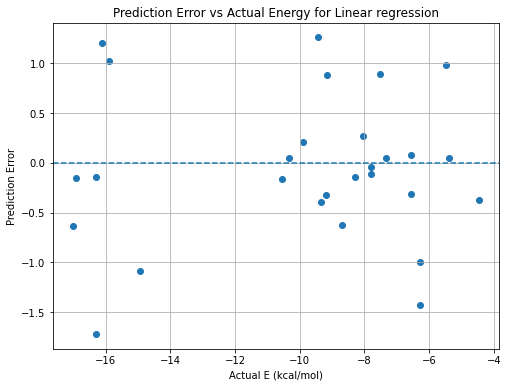

In [39]:

# =========================================================
# ERROR CALCULATION
# =========================================================
# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
error = y_test - y_pred

# =========================================================
# ERROR vs ACTUAL ENERGY
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, error)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Actual E (kcal/mol)")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Energy for Linear regression")

plt.grid(True)

plt.show()

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model = rf 
#r2_scores = cross_val_score(
#    rf,
#    X_scaled,
#    y,
#    cv=cv,
#    scoring='r2'
#)
print("Random Forest")
from sklearn.metrics import r2_score

all_predictions = []
fold_r2_scores = []
fold_number = 1

for train_idx, test_idx in cv.split(X_scaled):

    X_train = X_scaled.iloc[train_idx]
    X_test  = X_scaled.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)
    fold_r2_scores.append(fold_r2)
    print(f"Fold {fold_number} R² = {fold_r2:.4f}")

    fold_results = pd.DataFrame({

        "Fold": fold_number,

        "Dimer": df.iloc[test_idx]["dimer"].values,

        "Actual_E": y_test.values,

        "Predicted_E": y_pred,

        "Error": y_test.values - y_pred

    })

    all_predictions.append(fold_results)

    fold_number += 1

results_df = pd.concat(
    all_predictions,
    ignore_index=True
)
print("Mean R² :", np.mean(fold_r2_scores))
#print("Random Forest")

#print("R² scores:", r2_scores)

#print("Mean R² :", np.mean(r2_scores))

#print("Std R²  :", np.std(r2_scores))


Random Forest
Fold 1 R² = 0.9958
Fold 2 R² = 0.9865
Fold 3 R² = 0.9624
Fold 4 R² = 0.9533
Fold 5 R² = 0.9798
Mean R² : 0.9755774624151922


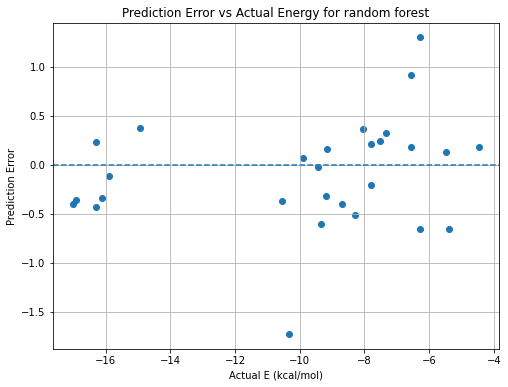

In [41]:

# =========================================================
# ERROR CALCULATION
# =========================================================
# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
error = y_test - y_pred

# =========================================================
# ERROR vs ACTUAL ENERGY
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, error)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Actual E (kcal/mol)")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Energy for random forest")

plt.grid(True)

plt.show()

In [42]:
results_df["Abs_Error"] = abs(results_df["Error"])

results_df.sort_values(
    "Abs_Error",
    ascending=False
).head(30)

,Fold,Dimer,Actual_E,Predicted_E,Error,Abs_Error
85,3,Cu_57,-16.86,-12.84845,-4.01155,4.01155
109,4,Cu_25,-6.28,-9.17365,2.89365,2.89365
103,4,Cu_5,-5.45,-8.03365,2.58365,2.58365
133,5,Cu_19,-10.32,-8.59225,-1.72775,1.72775
47,2,Cu_1,-6.64,-8.23205,1.59205,1.59205
83,3,Cu_54,-15.61,-14.14955,-1.46045,1.46045
124,5,Au_58,-6.29,-7.58870,1.29870,1.29870
105,4,Cu_8,-8.66,-9.93925,1.27925,1.27925
107,4,Cu_21,-7.46,-8.61765,1.15765,1.15765
86,3,Cu_59,-16.33,-15.19350,-1.13650,1.13650


In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model = xgb
#r2_scores = cross_val_score(
#    xgb,
#    X_scaled,
#    y,
#    cv=cv,
#    scoring='r2'
#)
print("XGBoost")
from sklearn.metrics import r2_score

all_predictions = []
fold_r2_scores = []
fold_number = 1

for train_idx, test_idx in cv.split(X_qtaim_d):

    X_train = X_qtaim_d.iloc[train_idx]
    X_test  = X_qtaim_d.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold_number} R² = {fold_r2:.4f}")

    fold_results = pd.DataFrame({

        "Fold": fold_number,

        "Dimer": df.iloc[test_idx]["dimer"].values,

        "Actual_E": y_test.values,

        "Predicted_E": y_pred,

        "Error": y_test.values - y_pred

    })

    all_predictions.append(fold_results)

    fold_number += 1

results_df = pd.concat(
    all_predictions,
    ignore_index=True
)

print("Mean R² :", np.mean(fold_r2_scores))
#print("XGBoost")

#print("R² scores:", r2_scores)

#print("Mean R² :", np.mean(r2_scores))

#print("Std R²  :", np.std(r2_scores))

XGBoost
Fold 1 R² = 0.9977
Fold 2 R² = 0.9948
Fold 3 R² = 0.9978
Fold 4 R² = 0.9930
Fold 5 R² = 0.9934
Mean R² : 0.9953259010739876


In [44]:
results_df["Abs_Error"] = abs(results_df["Error"])

results_df.sort_values(
    "Abs_Error",
    ascending=False
).head(30)

,Fold,Dimer,Actual_E,Predicted_E,Error,Abs_Error
109,4,Cu_25,-6.28,-7.382767,1.102767,1.102767
103,4,Cu_5,-5.45,-6.538719,1.088719,1.088719
134,5,Cu_20,-9.33,-8.318381,-1.011619,1.011619
47,2,Cu_1,-6.64,-7.482406,0.842406,0.842406
136,5,Cu_24,-8.68,-7.853127,-0.826873,0.826873
35,2,Ag_25,-5.62,-6.385955,0.765955,0.765955
21,1,Cu_17,-10.20,-9.561721,-0.638279,0.638279
76,3,Cu_6,-8.58,-7.971830,-0.608170,0.608170
84,3,Cu_56,-16.64,-16.115570,-0.524430,0.524430
34,2,Ag_24,-5.77,-6.271492,0.501492,0.501492


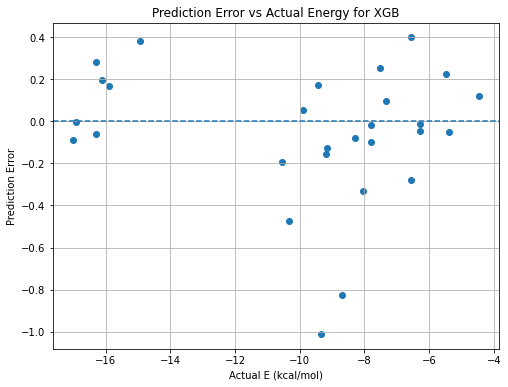

In [45]:

# =========================================================
# ERROR CALCULATION
# =========================================================
# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
error = y_test - y_pred

# =========================================================
# ERROR vs ACTUAL ENERGY
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, error)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Actual E (kcal/mol)")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Energy for XGB")

plt.grid(True)

plt.show()

In [46]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# CHOOSE DESCRIPTOR MATRIX
# =========================================================

# Examples:
# X_selected = X_ml
# X_selected = X_full
# X_selected = X_qm
# X_selected = X_qtaim
# X_selected = X_qtaim_d

X_selected = X_scaled

# =========================================================
# BLIND Cu SYSTEMS
# =========================================================

selected_dimers = [
    "Cu_1",
    "Cu_7",
    "Cu_13",
    "Cu_19",
    "Cu_25",
    "Cu_31",
    "Cu_39",
    "Cu_40",
    "Cu_48",
    "Cu_56"
]

# =========================================================
# TRAIN / TEST INDICES
# =========================================================

test_mask = df["dimer"].isin(selected_dimers)

train_mask = ~test_mask

# =========================================================
# SPLIT DATA
# =========================================================

X_train = X_selected.loc[train_mask]

X_test = X_selected.loc[test_mask]

y_train = y.loc[train_mask]

y_test = y.loc[test_mask]

# =========================================================
# MODEL
# =========================================================

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# =========================================================
# TRAIN
# =========================================================

xgb.fit(X_train, y_train)

# =========================================================
# PREDICT
# =========================================================

y_pred = xgb.predict(X_test)

# =========================================================
# METRICS
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("BLIND Cu TEST RESULTS")
print("==============================")

print("Training systems :", len(X_train))
print("Testing systems  :", len(X_test))

print("\nMAE  =", round(mae, 4))
print("RMSE =", round(rmse, 4))
print("R²   =", round(r2, 4))

# =========================================================
# DETAILED RESULTS
# =========================================================

results = pd.DataFrame({

    "Dimer": df.loc[test_mask, "dimer"].values,

    "Actual_E": y_test.values,

    "Predicted_E": y_pred,

    "Error": y_test.values - y_pred

})

results["Abs_Error"] = abs(results["Error"])

results = results.sort_values(
    "Abs_Error",
    ascending=False
)

print("\n==============================")
print("DETAILED PREDICTIONS")
print("==============================")

print(results)

# =========================================================
# SAVE
# =========================================================

results.to_csv(
    "Blind_Cu_Test_Results.csv",
    index=False
)


BLIND Cu TEST RESULTS
Training systems : 134
Testing systems  : 10

MAE  = 0.748
RMSE = 1.1425
R²   = 0.9299

DETAILED PREDICTIONS
   Dimer  Actual_E  Predicted_E     Error  Abs_Error
4  Cu_25     -6.28    -9.034697  2.754697   2.754697
3  Cu_19    -10.32    -8.759013 -1.560987   1.560987
0   Cu_1     -6.64    -8.200587  1.560587   1.560587
5  Cu_31    -17.17   -16.647144 -0.522856   0.522856
2  Cu_13     -9.13    -9.493213  0.363213   0.363213
9  Cu_56    -16.64   -16.984613  0.344613   0.344613
1   Cu_7     -8.70    -8.946104  0.246104   0.246104
6  Cu_39    -15.66   -15.580552 -0.079448   0.079448
8  Cu_48    -16.98   -17.011866  0.031866   0.031866
7  Cu_40    -16.22   -16.204363 -0.015637   0.015637


In [47]:
# Training only on copper complexes

In [48]:

import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# CHOOSE DESCRIPTOR MATRIX
# =========================================================

# Examples:
# X_selected = X_ml
# X_selected = X_qm
# X_selected = X_full

X_selected = X_scaled

# =========================================================
# GENERATE 6 Cu TEST SETS
# =========================================================

cu_sets = []

for start in range(1, 7):

    current_set = [

        f"Cu_{i}"

        for i in range(start, 61, 6)

    ]

    cu_sets.append(current_set)

# =========================================================
# STORAGE
# =========================================================

summary_results = []

all_predictions = []

# =========================================================
# LOOP OVER ALL 6 Cu TEST SETS
# =========================================================

for set_number, selected_dimers in enumerate(cu_sets, start=1):

    print("\n" + "="*60)
    print(f"Cu BLIND TEST SET {set_number}")
    print("="*60)

    print("Testing:")
    print(selected_dimers)

    # -----------------------------------------------------
    # Train/Test Split
    # -----------------------------------------------------

 #   test_mask = df["dimer"].isin(selected_dimers)

#    train_mask = ~test_mask

    test_mask = df["dimer"].isin(selected_dimers)

    train_mask = (
        df["dimer"].str.startswith("Cu_")
#       |
#        df["dimer"].str.startswith("Au_")
    )

    X_train = X_selected.loc[train_mask]

    X_test = X_selected.loc[test_mask]

    y_train = y.loc[train_mask]

    y_test = y.loc[test_mask]

    # -----------------------------------------------------
    # Model
    # -----------------------------------------------------

    xgb = XGBRegressor(

        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42

    )

    # -----------------------------------------------------
    # Train
    # -----------------------------------------------------

    xgb.fit(X_train, y_train)

    # -----------------------------------------------------
    # Predict
    # -----------------------------------------------------

    y_pred = xgb.predict(X_test)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    print("\nResults")

    print(f"MAE  = {mae:.4f}")

    print(f"RMSE = {rmse:.4f}")

    print(f"R²   = {r2:.4f}")

    # -----------------------------------------------------
    # Store Summary
    # -----------------------------------------------------

    summary_results.append({

        "Set": set_number,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2

    })

    # -----------------------------------------------------
    # Store Detailed Predictions
    # -----------------------------------------------------

    temp = pd.DataFrame({

        "Set": set_number,

        "Dimer": df.loc[test_mask, "dimer"].values,

        "Actual_E": y_test.values,

        "Predicted_E": y_pred,

        "Error": y_test.values - y_pred

    })

    temp["Abs_Error"] = abs(temp["Error"])

    temp = temp.sort_values(
        "Abs_Error",
        ascending=False
    )

    all_predictions.append(temp)

# =========================================================
# FINAL DATAFRAMES
# =========================================================

summary_df = pd.DataFrame(summary_results)

predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

# =========================================================
# DISPLAY SUMMARY
# =========================================================

print("\n")
print("="*70)
print("OVERALL Cu BLIND TEST SUMMARY")
print("="*70)

print(summary_df)

print("\nAverage Performance Across All 6 Sets")

print("Mean MAE  :", round(summary_df["MAE"].mean(), 4))

print("Std MAE   :", round(summary_df["MAE"].std(), 4))

print("Mean RMSE :", round(summary_df["RMSE"].mean(), 4))

print("Mean R²   :", round(summary_df["R2"].mean(), 4))

# =========================================================
# DISPLAY WORST PREDICTIONS
# =========================================================

print("\n")
print("="*70)
print("TOP 30 WORST PREDICTIONS")
print("="*70)

print(
    predictions_df
    .sort_values("Abs_Error", ascending=False)
    .head(30)
)

# =========================================================
# SAVE FILES
# =========================================================

summary_df.to_csv(
    "Cu_Blind_Test_Summary.csv",
    index=False
)

predictions_df.to_csv(
    "Cu_Blind_Test_Predictions.csv",
    index=False
)


Cu BLIND TEST SET 1
Testing:
['Cu_1', 'Cu_7', 'Cu_13', 'Cu_19', 'Cu_25', 'Cu_31', 'Cu_37', 'Cu_43', 'Cu_49', 'Cu_55']

Results
MAE  = 0.0128
RMSE = 0.0148
R²   = 1.0000

Cu BLIND TEST SET 2
Testing:
['Cu_2', 'Cu_8', 'Cu_14', 'Cu_20', 'Cu_26', 'Cu_32', 'Cu_38', 'Cu_44', 'Cu_50', 'Cu_56']

Results
MAE  = 0.0095
RMSE = 0.0120
R²   = 1.0000

Cu BLIND TEST SET 3
Testing:
['Cu_3', 'Cu_9', 'Cu_15', 'Cu_21', 'Cu_27', 'Cu_33', 'Cu_39', 'Cu_45', 'Cu_51', 'Cu_57']

Results
MAE  = 0.0129
RMSE = 0.0159
R²   = 1.0000

Cu BLIND TEST SET 4
Testing:
['Cu_4', 'Cu_10', 'Cu_16', 'Cu_22', 'Cu_28', 'Cu_34', 'Cu_40', 'Cu_46', 'Cu_52', 'Cu_58']

Results
MAE  = 0.0062
RMSE = 0.0075
R²   = 1.0000

Cu BLIND TEST SET 5
Testing:
['Cu_5', 'Cu_11', 'Cu_17', 'Cu_23', 'Cu_29', 'Cu_35', 'Cu_41', 'Cu_47', 'Cu_53', 'Cu_59']

Results
MAE  = 0.0140
RMSE = 0.0171
R²   = 1.0000

Cu BLIND TEST SET 6
Testing:
['Cu_6', 'Cu_12', 'Cu_18', 'Cu_24', 'Cu_30', 'Cu_36', 'Cu_42', 'Cu_48', 'Cu_54', 'Cu_60']

Results
MAE  = 0.0079
RMSE 

In [49]:
# Testing for external validation

In [50]:

import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# CHOOSE DESCRIPTOR MATRIX
# =========================================================

# Example:
# X_selected = X_ml
# X_selected = X_full
# X_selected = X_qm

X_selected = X_qtaim

# =========================================================
# RANDOMLY HIDE 5 Cu COMPLEXES
# =========================================================

np.random.seed(200)

cu_dimers = df[
    df["dimer"].str.startswith("Cu_")
]["dimer"].tolist()

hidden_dimers = np.random.choice(
    cu_dimers,
    size=5,
    replace=False
)

print("\nHidden Cu Complexes")
print(hidden_dimers)

# =========================================================
# REMOVE THEM COMPLETELY
# =========================================================

hidden_mask = df["dimer"].isin(hidden_dimers)

visible_mask = ~hidden_mask

X_visible = X_selected.loc[visible_mask]

y_visible = y.loc[visible_mask]

# =========================================================
# NORMAL 5-FOLD CV ON REMAINING DATA
# =========================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_r2_scores = []

for fold_number, (train_idx, test_idx) in enumerate(
    cv.split(X_visible),
    start=1
):

    X_train = X_visible.iloc[train_idx]
    X_test = X_visible.iloc[test_idx]

    y_train = y_visible.iloc[train_idx]
    y_test = y_visible.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)

    fold_r2_scores.append(fold_r2)

    print(
        f"Fold {fold_number} R² = "
        f"{fold_r2:.4f}"
    )

print("\nMean CV R² =", np.mean(fold_r2_scores))

# =========================================================
# FINAL MODEL
# =========================================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_visible, y_visible)

# =========================================================
# PREDICT HIDDEN Cu SYSTEMS
# =========================================================

X_hidden = X_selected.loc[hidden_mask]

y_hidden = y.loc[hidden_mask]

y_pred_hidden = model.predict(X_hidden)

# =========================================================
# RESULTS
# =========================================================

results = pd.DataFrame({

    "Dimer":
    df.loc[hidden_mask, "dimer"].values,

    "Actual_E":
    y_hidden.values,

    "Predicted_E":
    y_pred_hidden,

    "Error":
    y_hidden.values - y_pred_hidden

})

results["Abs_Error"] = abs(
    results["Error"]
)

results = results.sort_values(
    "Abs_Error",
    ascending=False
)

# =========================================================
# METRICS
# =========================================================

mae = mean_absolute_error(
    y_hidden,
    y_pred_hidden
)

rmse = np.sqrt(
    mean_squared_error(
        y_hidden,
        y_pred_hidden
    )
)

r2 = r2_score(
    y_hidden,
    y_pred_hidden
)

# =========================================================
# PRINT
# =========================================================

print("\n")
print("="*60)
print("EXTERNAL Cu PREDICTION TEST")
print("="*60)

print(results)

print("\nMAE  =", round(mae,4))
print("RMSE =", round(rmse,4))
print("R²   =", round(r2,4))

# =========================================================
# SAVE
# =========================================================

#results.to_csv(
#    "External_Cu_Predictions.csv",
#    index=False
#)
print("\n")
print("="*60)
print("EXTERNAL Cu PREDICTION RESULTS")
print("="*60)

print(
    results.sort_values(
        "Abs_Error",
        ascending=False
    )
)


Hidden Cu Complexes
['Cu_18' 'Cu_6' 'Cu_34' 'Cu_49' 'Cu_59']
Fold 1 R² = 0.9831
Fold 2 R² = 0.9840
Fold 3 R² = 0.9605
Fold 4 R² = 0.9658
Fold 5 R² = 0.9162

Mean CV R² = 0.9619355762475781


EXTERNAL Cu PREDICTION TEST
   Dimer  Actual_E  Predicted_E     Error  Abs_Error
4  Cu_59    -16.33   -15.241955 -1.088045   1.088045
2  Cu_34    -17.13   -16.471975 -0.658025   0.658025
0   Cu_6     -8.58    -8.270958 -0.309042   0.309042
1  Cu_18     -9.82    -9.591910 -0.228090   0.228090
3  Cu_49    -17.14   -17.349630  0.209630   0.209630

MAE  = 0.4986
RMSE = 0.6014
R²   = 0.9748


EXTERNAL Cu PREDICTION RESULTS
   Dimer  Actual_E  Predicted_E     Error  Abs_Error
4  Cu_59    -16.33   -15.241955 -1.088045   1.088045
2  Cu_34    -17.13   -16.471975 -0.658025   0.658025
0   Cu_6     -8.58    -8.270958 -0.309042   0.309042
1  Cu_18     -9.82    -9.591910 -0.228090   0.228090
3  Cu_49    -17.14   -17.349630  0.209630   0.209630
